In [1]:
from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.regression import TemplateConfig, PySRParams, ModelParametrizer

from sympy import Matrix, Float, preorder_traversal
from warnings import catch_warnings, simplefilter

from numpy import log
import numpy as np

from scipy.linalg import cholesky, solve_triangular

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
import cProfile

_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Load reference model
parser = ModelParser("../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [3]:
T = 200
gz = lambda seed: Shock(T, "norm", multivar=True, seed=seed).shock_generator()
r = lambda seed: Shock(T, "norm", multivar=False, seed=seed).shock_generator()

sim_dgp = sol.sim(
    T=T,
    shocks={"g,z": gz(0), "r": r(1)},
    observables=True,
)

In [4]:
# Use DGP observables as kalman filter targets in reference model
obs = np.column_stack([sim_dgp["OutGap"], sim_dgp["Infl"], sim_dgp["Rate"]])[1:, :]
kf = sol.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=True,
)

N, n_obs = kf.innov.shape
std_innov = np.empty_like(kf.innov)

for t in range(N):
    S_t = 0.5 * (kf.S[t] + kf.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov[t] = solve_triangular(L_t, kf.innov[t], lower=True)

R estimation optimization successful.
Using estimated R matrix:
 [[1.06302491e-12 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 4.00472117e-09 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.13124281e-13]]
Log-likelihood: -783.7425832414344


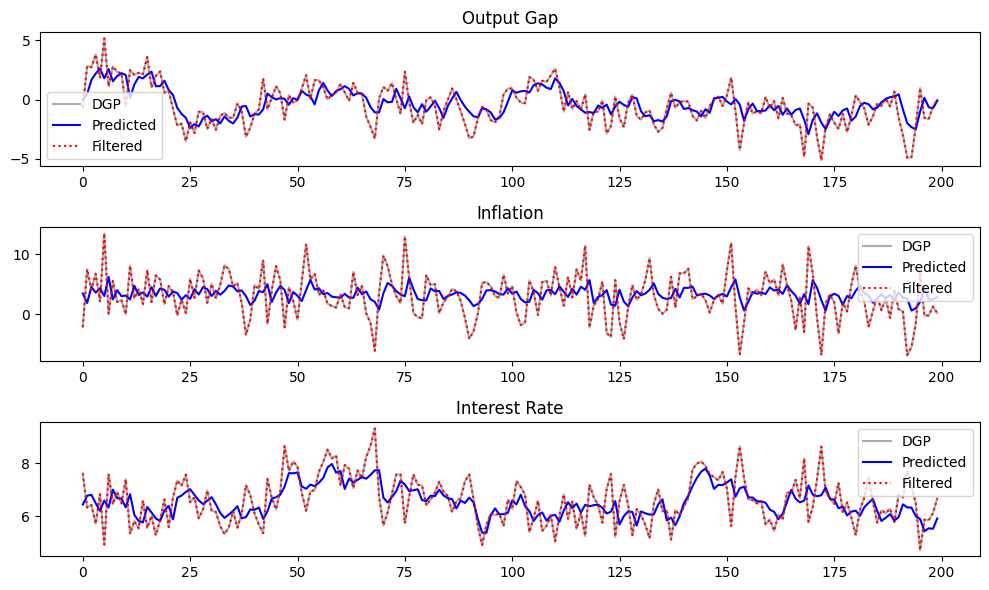

In [5]:
# Plot Filter Outputs
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)
ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

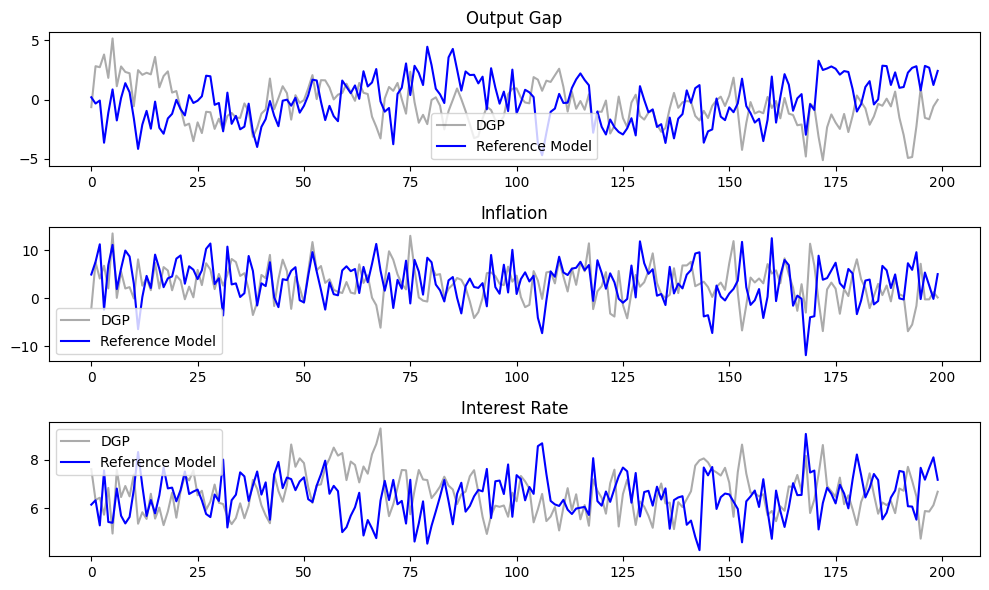

In [6]:
# Simulation against DGP
sim_ref = sol.sim(
    T=T,
    shocks={"g,z": gz(2), "r": r(2)},
    observables=True,
)

ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), ref[:, 0], label="Reference Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), ref[:, 1], label="Reference Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), ref[:, 2], label="Reference Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

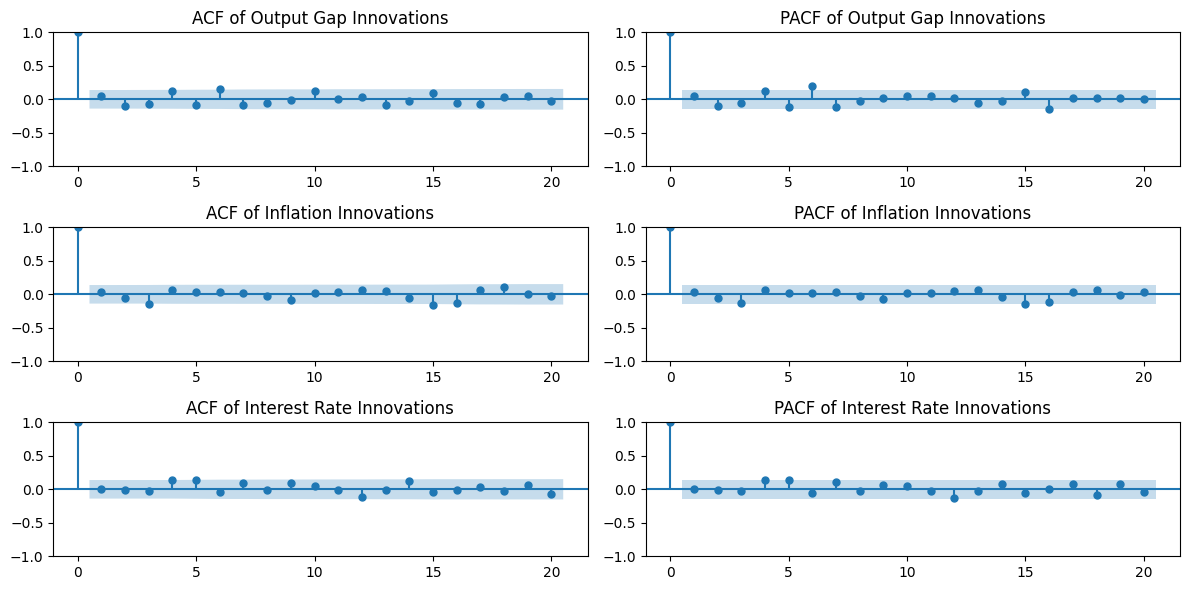

Ljung-Box test for Output Gap Innovations:
    LB Stat=25.45
    p-value=0.1848

Ljung-Box test for Inflation Innovations:
    LB Stat=23.17
    p-value=0.2808

Ljung-Box test for Interest Rate Innovations:
    LB Stat=22.14
    p-value=0.3329



In [7]:
# Plot AFC/PACF of kalman innovations to see if the misspecification appears in the form of serial correlation

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov[:, 0], ax=ax[0, 0], lags=20)
plot_pacf(std_innov[:, 0], ax=ax[0, 1], lags=20)
ax[0, 0].set_title("ACF of Output Gap Innovations")
ax[0, 1].set_title("PACF of Output Gap Innovations")

plot_acf(std_innov[:, 1], ax=ax[1, 0], lags=20)
plot_pacf(std_innov[:, 1], ax=ax[1, 1], lags=20)
ax[1, 0].set_title("ACF of Inflation Innovations")
ax[1, 1].set_title("PACF of Inflation Innovations")

plot_acf(std_innov[:, 2], ax=ax[2, 0], lags=20)
plot_pacf(std_innov[:, 2], ax=ax[2, 1], lags=20)
ax[2, 0].set_title("ACF of Interest Rate Innovations")
ax[2, 1].set_title("PACF of Interest Rate Innovations")

plt.tight_layout()
plt.show()
# Apply Ljung-Box test to check for serial correlation in innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov[:, i], lags=[20])
    print(
        f"Ljung-Box test for {var} Innovations:\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [8]:
# Run a Breusch-Pagan test to check for heteroskedasticity in the residuals

# Design Matrices for BP test
x_idx = sol.compiled.idx["x"]
pi_idx = sol.compiled.idx["Pi"]
r_idx = sol.compiled.idx["r"]

pi_star = sol.config.calibration.parameters["pi_star"]
r_star = sol.config.calibration.parameters["r_star"]

C = np.ones((len(std_innov), 1))

# Output Gap Matrix
ogap = np.column_stack([C, kf.x_filt[:, x_idx]])

# Inflation Matrix
infl_ss = np.full((len(std_innov), 1), pi_star)
infl = np.column_stack([C, kf.x_filt[:, pi_idx], infl_ss])

# Interest Rate Matrix
r_ss = np.full((len(std_innov), 1), r_star + pi_star)  # Nominal rate steady state
rate = np.column_stack([C, kf.x_filt[:, r_idx], r_ss + pi_star])

exogs = [ogap, infl, rate]
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = het_breuschpagan(std_innov[:, i], exogs[i])
    print(
        f"Breusch-Pagan test for {var} Residuals:\n    BP Stat={test[0]:.2f}\n    p-value={test[1]:.4f}\n"
    )

Breusch-Pagan test for Output Gap Residuals:
    BP Stat=7.50
    p-value=0.0062

Breusch-Pagan test for Inflation Residuals:
    BP Stat=0.51
    p-value=0.7756

Breusch-Pagan test for Interest Rate Residuals:
    BP Stat=0.01
    p-value=0.9939



In [9]:
mu = std_innov.mean(axis=0)
Sigma = np.cov(std_innov, rowvar=False)

print("Mean:", mu)
print("Covariance:\n", Sigma)
print("Off-diagonals:\n", Sigma - np.diag(np.diag(Sigma)))

Mean: [-0.11035455  0.03527754  0.05544236]
Covariance:
 [[ 0.82873788 -0.01979933  0.0323622 ]
 [-0.01979933  1.00031527  0.04290025]
 [ 0.0323622   0.04290025  0.9419768 ]]
Off-diagonals:
 [[ 0.         -0.01979933  0.0323622 ]
 [-0.01979933  0.          0.04290025]
 [ 0.0323622   0.04290025  0.        ]]


In [10]:
kf.S

array([[[ 5.99192258, 16.06267783, -1.8154452 ],
        [16.06267783, 53.09644239, -5.32139907],
        [-1.8154452 , -5.32139907,  3.13749051]],

       [[ 1.76893018,  4.5627539 , -0.79142372],
        [ 4.5627539 , 15.31105848, -2.52232452],
        [-0.79142372, -2.52232452,  0.5184    ]],

       [[ 1.76893018,  4.5627539 , -0.79142372],
        [ 4.5627539 , 15.31105848, -2.52232452],
        [-0.79142372, -2.52232452,  0.5184    ]],

       ...,

       [[ 1.76893018,  4.5627539 , -0.79142372],
        [ 4.5627539 , 15.31105848, -2.52232452],
        [-0.79142372, -2.52232452,  0.5184    ]],

       [[ 1.76893018,  4.5627539 , -0.79142372],
        [ 4.5627539 , 15.31105848, -2.52232452],
        [-0.79142372, -2.52232452,  0.5184    ]],

       [[ 1.76893018,  4.5627539 , -0.79142372],
        [ 4.5627539 , 15.31105848, -2.52232452],
        [-0.79142372, -2.52232452,  0.5184    ]]], shape=(200, 3, 3))